# Plot from dicts

## Bring Plots from plotting_df_77_97_mrn

### Bring ***imports*** & ***det functions from*** plotting_df_77_97_mrn

#### ***imports*** 

In [1]:
# Imports required for Loading, sorting .csx files to create specific data sets ie mrn inbody readings. 
%run ./sys_funcs.py              # loads all the def functions in sys_funcs.py into memory
#import sys_funcs                 # gives access to these def function digitalform that are in memory
from pathlib import Path
import csv
import pandas as pd
import numpy as np
#import tkinter as tk
import pickle
from pathlib import Path
import csv
import os
import sys
import ipywidgets as widgets 
from datetime import datetime
from datetime import time
from sys_funcs import read_csv_to_array
from sys_funcs import clean_wsl_path
from sys_funcs import array_to_dt_row_dict
from sys_funcs import make_blnk_update_row_dict
from sys_funcs import transpose_csv_to_col_dict
#from sys_funcs import update_values_with_config, get_update_result
from sys_funcs import transfer_updates
from sys_funcs import get_dtv_range
from sys_funcs import universal_import
from sys_funcs import parse_inbody_timestamp
from sys_funcs import build_lut
from sys_funcs import extract_a_column_as_df
from sys_funcs import extract_multicolumns_as_df
from sys_funcs import validate_and_sort_timestamps
from sys_funcs import extract_and_filter_by_time_window
from sys_funcs import read_file_dual_path
from sys_funcs import write_file_dual_path
from sys_funcs import asc_to_csv_cnv
from collections.abc import Mapping
import re
import pandas as pd
from pathlib import Path
import pickle
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import unicodedata
import re
import pandas as pd
from pathlib import Path
import pickle
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import unicodedata
import re
#from sys_funcs import 

#### ***det functions***

In [93]:
def read_from_pkl(name):     # name is a string: read_from_pkl("name")import pickle and fill obj = name
    filename = f"{name}.pkl"
    print(filename)
    with open(filename, "rb") as f:
        loaded_obj = pickle.load(f)
    globals()[name] = loaded_obj
    print(f"{name} updated from {filename}")     # returns variable called name fill with update data
    

In [132]:
# read_from_pkl("plt_lst_dct")

In [39]:
def write_to_pkl(name):   # name is a string: write_to_pkl("name.pkl")
    import pickle
    import inspect
    
    # Access caller frame
    frame = inspect.currentframe().f_back

    # Pull the object from caller's local variables
    if name not in frame.f_locals:
        raise NameError(f"Variable '{name}' does not exist in caller scope")

    obj = frame.f_locals[name]

    # Write to pickle
    filename = f"{name}.pkl"
    with open(filename, "wb") as f:
        pickle.dump(obj, f)

    print(f"{name} written to {filename}")
    return None


In [135]:
def df_to_dct(df, name="ib_dct"):
    """
    Convert a DataFrame into a dictionary of columns.
    Keys = column names
    Values = pandas Series (or arrays if preferred)
    """
    dct = {col: df[col] for col in df.columns}
    print(f"{name} created with {len(dct)} keys")
    return dct


In [136]:
ib_dct = df_to_dct(df_77_97_mrn, "ib_dct")

ib_dct created with 21 keys


In [213]:
# verify list(ib_dct.keys())

In [98]:
# write_to_pkl("plt_lst_dct")

In [144]:
def make_plt_lst_x(plt_list_nm, dct_i, key_i, dct_j, key_j):         # Make a new plt_lst_x
    return {
        0: plt_list_nm,
        1: dct_i,
        2: key_i,
        3: dct_j,
        4: key_j
    }


In [151]:
# plt_list_nm read_fro make_plt_lst_x(plt_list_nm, dct_i, key_i, dct_j, key_j)

In [169]:
# fill in varibles to make plt_lst_x [used to added to plt_lst_dct
plt_list_nm = "weightXecw/tbw"
dct_i = "ib_dct"
key_i = "weight"
dct_j = "ib_dct"
key_j = "ecw/tbw"
plt_lst_x = make_plt_lst_x(plt_list_nm, dct_i, key_i, dct_j, key_j)

In [181]:
# fill in varibles to make plt_lst_x [used to added to plt_lst_dct
plt_list_nm = "icwXecw/tbw"
dct_i = "ib_dct"
key_i = "icw_(intracellular_water)"
dct_j = "ib_dct"
key_j = "ecw/tbw"
plt_lst_x = make_plt_lst_x(plt_list_nm, dct_i, key_i, dct_j, key_j)

In [182]:
# verify 
plt_lst_x       # ok

{0: 'icwXecw/tbw',
 1: 'ib_dct',
 2: 'icw_(intracellular_water)',
 3: 'ib_dct',
 4: 'ecw/tbw'}

In [183]:
def add_row(plt_lst_dct, plt_lst_x):   # add the new row to "plt_lst_dct"
    next_idx = len(plt_lst_dct) + 1
    row_id = f"row_{next_idx:03d}"
    plt_lst_dct[row_id] = plt_lst_x
    return row_id


In [215]:
#  verify plt_lst_x       # Shows the "plt_lst_x" to be plotted OK

In [216]:
# verify plt_lst_dct  # verify the contents of "plt_lst_dct"

In [190]:
# verify_
(plt_lst_dct)

{'row_007': {0: 'weightXecw/tbw',
  1: 'ib_dct',
  2: 'weight',
  3: 'ib_dct',
  4: 'ecw/tbw'},
 'row_002': {0: 'icwXecw/tbw',
  1: 'ib_dct',
  2: 'icw_(intracellular_water)',
  3: 'ib_dct',
  4: 'ecw/tbw'}}

In [176]:
def delete_row_by_id(plt_lst_dct, row_id):  # delete row of "row_id" from "plt_lst_dct"
    if row_id in plt_lst_dct:
        del plt_lst_dct[row_id]
    return plt_lst_dct


In [177]:
def delete_row_by_name(plt_lst_dct, plt_list_nm):  # delete row of " plt_list_nm" from "plt_lst_dct"
    to_delete = [rid for rid, row in plt_lst_dct.items() if row[0] == plt_list_nm]
    for rid in to_delete:
        del plt_lst_dct[rid]
    return plt_lst_dct


In [188]:
plt_list_nm = "smm_vfa"
delete_row_by_name(plt_lst_dct, plt_list_nm)

{'row_007': {0: 'weightXecw/tbw',
  1: 'ib_dct',
  2: 'weight',
  3: 'ib_dct',
  4: 'ecw/tbw'},
 'row_002': {0: 'icwXecw/tbw',
  1: 'ib_dct',
  2: 'icw_(intracellular_water)',
  3: 'ib_dct',
  4: 'ecw/tbw'}}

In [206]:
def dispatch_by_name(plt_lst_dct, plt_list_nm):  # read row specified to give a "plt_lst_x"
    for row in plt_lst_dct.values():
        if row[0] == plt_list_nm:
            return row
    return None


In [33]:
def dispatch_by_row_id(plt_lst_dct, row_id):       # read row specified to give a "plt_lst_x"
    return plt_lst_dct.get(row_id, None)


In [36]:
def find_by_substring(plt_lst_dct, substring):  # find the row with a "plt_lst_nm" conatins the substring
    return {
        rid: row for rid, row in plt_lst_dct.items()
        if substring in row[0]
    }


In [191]:
def find_duplicates(plt_lst_dct):         # lst the duplicate rows so they can be fixed or deleded
    from collections import Counter
    
    names = [row[0] for row in plt_lst_dct.values()]
    dupes = {nm for nm, cnt in Counter(names).items() if cnt > 1}
    return {
        rid: row for rid, row in plt_lst_dct.items()
        if row[0] in dupes
    }


##### ***read & write from Local Storage***

In [43]:
 read_from_pkl("df_77_97_mrn")     # name is a string: read_from_pkl("ib_dct")import pickle


df_77_97_mrn.pkl
df_77_97_mrn updated from df_77_97_mrn.pkl


In [193]:
 read_from_pkl("ib_dct")     # name is a string: read_from_pkl("ib_dct")import pickle


ib_dct.pkl
ib_dct updated from ib_dct.pkl


In [194]:
write_to_pkl("df_77_97_mrn")   # name is a string: write_to_pkl("df_77_97_mrn")

df_77_97_mrn written to df_77_97_mrn.pkl


In [195]:
write_to_pkl("ib_dct")   # name is a string: write_to_pkl("ib_dct")

ib_dct written to ib_dct.pkl


In [7]:
# def read froms XL

In [8]:
# def write to XL

##### ***Slct_frm_dct***

##### ***add,edit,delete***

##### ***output***

In [196]:
def plot_multi_dual(df, *cols, save_pdf=True):     
    
    #from plotting _df_77_97_mrn    
    # this uses a "df" for the x-axis and a "plt_lst_x" for the 2 cols that are plotted 
    # on screen, and optionally plots them into a PDF file for storage or printing
    
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import pandas as pd
    import os, re

    # Work on a safe copy
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # Color cycle (extend if needed)
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    fig, ax = plt.subplots(figsize=(12, 5))

    # First column on left axis
    ax.plot(
        df["timestamp"],
        df[cols[0]],
        marker="o",
        color=color_cycle[0],
        label=cols[0]
    )
    ax.set_ylabel(cols[0], color=color_cycle[0])
    ax.tick_params(axis="y", labelcolor=color_cycle[0])
    axes = [ax]

    # Additional columns on stacked right axes
    for i, col in enumerate(cols[1:], start=1):
        ax_new = ax.twinx()
        ax_new.spines.right.set_position(("axes", 1 + 0.1 * (i - 1)))

        color = color_cycle[i % len(color_cycle)]
        ax_new.plot(
            df["timestamp"],
            df[col],
            marker="o",
            color=color,
            label=col
        )
        ax_new.set_ylabel(col, color=color)
        ax_new.tick_params(axis="y", labelcolor=color)

        axes.append(ax_new)

    # Minor ticks every day
    ax.xaxis.set_minor_locator(mdates.DayLocator())

    # Major ticks weekly (Mondays)
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

    # Rotate major tick labels for readability
    for label in ax.get_xticklabels(which="major"):
        label.set_rotation(45)
        label.set_ha("right")

    # Grid on major ticks
    ax.grid(which="major", linestyle="--", linewidth=0.7, alpha=0.7)

    plt.xticks(rotation=45)
    plt.title(" / ".join(cols) + " over time")
    plt.tight_layout()

    # === SAVE BLOCK (PDF, WSL-safe, sanitized filename) ===
    if save_pdf:
        save_dir = "/mnt/c/Users/bhuns/OneDrive/___ib_plots"
        os.makedirs(save_dir, exist_ok=True)

        # Build clean filename
        chart_title = " vs ".join(cols)
        chart_title = chart_title.replace("/", "_")
        chart_title = re.sub(r'[^A-Za-z0-9_-]+', '_', chart_title)

        # Add timestamp
        from datetime import datetime
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        chart_title = f"{timestamp}_{chart_title}"

        pdf_path = f"{save_dir}/{chart_title}.pdf"

        fig.savefig(pdf_path, dpi=300, bbox_inches="tight")

    plt.show()

#### ***Call_functions***

##### using def from plottingdf77_97 .....

In [199]:
ib_dct

,timestamp,dtv,weight,vfa_(visceral_fat_area),ecw/tbw,ecw/tbw_of_left_leg_x,ecw/tbw_of_right_leg_x,bmr_(basal_metabolic_rate),smm_(skeletal_muscle_mass),khz-whole_body_phase_angle,...,ecw_(extracellular_water),icw_(intracellular_water),ecw/tbw_of_left_leg_y,ecw/tbw_of_right_leg_y,ecw_of_left_leg,ecw_of_right_leg,lower_limit_(ecw_of_left_leg_normal_range),lower_limit_(ecw_of_right_leg_normal_range),upper_limit_(ecw_of_left_leg_normal_range),upper_limit_(ecw_of_right_leg_normal_range)
0,2025-09-18 08:09:17,45916.0,260.1,172.4,0.411,0.417,0.419,2130.0,97.4,3.5,...,54.7,78.0,0.417,0.419,10.32,10.58,6.75,6.75,8.25,8.25
1,2025-09-19 06:50:43,45917.0,258.5,177.9,0.409,0.414,0.416,2093.0,95.5,3.7,...,53.1,76.5,0.414,0.416,10.05,10.30,6.75,6.75,8.25,8.25
2,2025-09-22 08:14:10,45920.0,258.2,183.0,0.408,0.413,0.415,2082.0,95.0,3.7,...,52.5,76.3,0.413,0.415,9.85,10.05,6.75,6.75,8.25,8.25
3,2025-09-23 07:55:49,45921.0,260.8,176.2,0.410,0.416,0.416,2126.0,97.2,3.6,...,54.2,78.0,0.416,0.416,10.30,10.27,6.75,6.75,8.25,8.25
4,2025-09-24 08:03:05,45922.0,259.8,176.1,0.408,0.413,0.415,2129.0,97.7,3.7,...,54.0,78.3,0.413,0.415,9.94,10.05,6.75,6.75,8.25,8.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,2026-06-09 07:52:23,46180.0,264.7,176.6,0.403,0.410,0.408,2157.0,100.1,4.3,...,54.0,80.2,0.410,0.408,10.10,9.97,6.75,6.75,8.25,8.25
242,2026-06-10 07:51:50,46181.0,266.9,178.3,0.403,0.409,0.408,2191.0,102.1,4.1,...,55.3,81.6,0.409,0.408,9.88,9.85,6.75,6.75,8.25,8.25
243,2026-06-11 06:38:21,46182.0,266.8,182.1,0.404,0.410,0.408,2162.0,100.3,4.1,...,54.5,80.2,0.410,0.408,9.99,9.90,6.75,6.75,8.25,8.25
244,2026-06-12 08:08:17,46183.0,265.3,183.7,0.404,0.411,0.408,2134.0,98.5,4.1,...,53.6,78.9,0.411,0.408,10.10,9.94,6.75,6.75,8.25,8.25


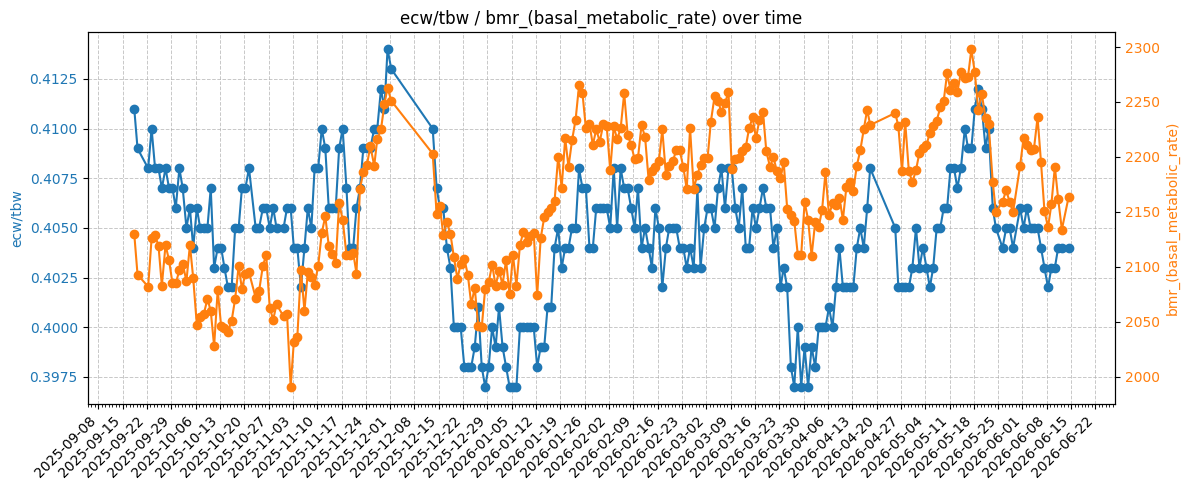

In [205]:
# Plots by subject inflamation and BMR
plt_lst_x = ["ecw/tbw", 'bmr_(basal_metabolic_rate)']
plot_multi_dual(ib_dct, *plt_lst_x,save_pdf=True )
# plot_multi_dual(ib_dct, *plt_lst,save_pdf=True )

##### Import ***Dictionaries*** and  ***Data from df***

In [133]:
read_from_pkl("df_77_97_mrn")  # creats obj with name in ("")

df_77_97_mrn.pkl
df_77_97_mrn updated from df_77_97_mrn.pkl


In [198]:
ib_dct = df_77_97_mrn

In [45]:
write_to_pkl("df_77_97_mrn")    # name is a string: write_to_pkl("name.pkl"

df_77_97_mrn written to df_77_97_mrn.pkl


In [56]:
## plt_lst_dct ={}        # WARNING DELETE ALL CONTENTS OF "plt_lst_dct() "

In [61]:
# verify_plt_lst_dct(plt_lst_dct)

### ***source dat_cols*** to plot from ***df_77_97_mrn.columns.tolist***

In [64]:
df_77_97_mrn.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['timestamp', 'dtv', 'weight', 'vfa_(visceral_fat_area)', 'ecw/tbw',
       'ecw/tbw_of_left_leg_x', 'ecw/tbw_of_right_leg_x',
       'bmr_(basal_metabolic_rate)', 'smm_(skeletal_muscle_mass)',
       'khz-whole_body_phase_angle', 'whole_body_ecw/tbw_t_score',
       'ecw_(extracellular_water)', 'icw_(intracellular_water)',
       'ecw/tbw_of_left_leg_y', 'ecw/tbw_of_right_leg_y', 'ecw_of_left_leg',
       'ecw_of_right_leg', 'lower_limit_(ecw_of_left_leg_normal_range)',
       'lower_limit_(ecw_of_right_leg_normal_range)',
       'upper_limit_(ecw_of_left_leg_normal_range)',
       'upper_limit_(ecw_of_right_leg_normal_range)'],
      dtype='object')>

In [62]:
# make_plt_lst_x(plt_list_nm, dct_i, key_i, dct_j, key_j)

### Add a 1st row

#### fill in the info to male a plt_lst_x

In [72]:
plt_lst_x = make_plt_lst_x(            # filled in from dat_col list of  "df_77_97_mrn"
    "smmXvfa",
    "df_77_97_mrn",
    "smm_(skeletal_muscle_mass)",
    "df_77_97_mrn",
    "vfa_(visceral_fat_area)"
)


In [73]:
plt_lst_x

{0: 'smmXvfa',
 1: 'df_77_97_mrn',
 2: 'smm_(skeletal_muscle_mass)',
 3: 'df_77_97_mrn',
 4: 'vfa_(visceral_fat_area)'}

#### use ***plt_lst_x*** to populate ***plt_lst_dct***

In [74]:
add_row(plt_lst_dct, plt_lst_x)       # add new row "plt_lst_x" to "plt_lst_dct"

'row_001'

#### Verify new ***plt_lst_dct***

In [76]:
# verify 
plt_lst_dct

{'row_001': {0: 'smmXvfa',
  1: 'df_77_97_mrn',
  2: 'smm_(skeletal_muscle_mass)',
  3: 'df_77_97_mrn',
  4: 'vfa_(visceral_fat_area)'}}

### Add a 2nd row

#### fill in the info to male a plt_lst_x

In [78]:
plt_lst_x = make_plt_lst_x(            # filled in from dat_col list of  "df_77_97_mrn"
    "smmXphangl",
    "df_77_97_mrn",
    "smm_(skeletal_muscle_mass)",
    "df_77_97_mrn",
    'khz-whole_body_phase_angle'
)


#### use ***plt_lst_x*** to populate ***plt_lst_dct***

In [79]:
add_row(plt_lst_dct, plt_lst_x)       # add new row "plt_lst_x" to "plt_lst_dct"

'row_002'

#### Verify new ***plt_lst_dct***

In [80]:
# verify 
plt_lst_dct

{'row_001': {0: 'smmXvfa',
  1: 'df_77_97_mrn',
  2: 'smm_(skeletal_muscle_mass)',
  3: 'df_77_97_mrn',
  4: 'vfa_(visceral_fat_area)'},
 'row_002': {0: 'smmXphangl',
  1: 'df_77_97_mrn',
  2: 'smm_(skeletal_muscle_mass)',
  3: 'df_77_97_mrn',
  4: 'khz-whole_body_phase_angle'}}

### Use these to create a plot

#### verify before using ***plt_lst_dct***

In [81]:
# verify 
plt_lst_dct

{'row_001': {0: 'smmXvfa',
  1: 'df_77_97_mrn',
  2: 'smm_(skeletal_muscle_mass)',
  3: 'df_77_97_mrn',
  4: 'vfa_(visceral_fat_area)'},
 'row_002': {0: 'smmXphangl',
  1: 'df_77_97_mrn',
  2: 'smm_(skeletal_muscle_mass)',
  3: 'df_77_97_mrn',
  4: 'khz-whole_body_phase_angle'}}

#### Select ***plt_lst_x*** from ***plt_lst_dct***

In [86]:
plt_lst_x = dispatch_by_row_id(plt_lst_dct,"row_002")

In [88]:
# verify plt_lst_x

#### Use ***plt_lst_x*** to make a plot

In [91]:
plot_multi_dual(df, plt_lst_x, save_pdf=True)

NameError: name 'df' is not defined